In [1]:
from typing import TypedDict,Literal

In [5]:
class PortfolioState(TypedDict):
  amount_usd: float
  total_usd: float
  total: float
  target_currency: Literal["EUR","INR"]

In [6]:
def calc_total(state:PortfolioState) -> PortfolioState:
  state['total_usd'] = state['amount_usd']*1.08
  return state

In [7]:
def convert_inr(state:PortfolioState) -> PortfolioState :
  state['total'] = state['total_usd']*85
  return state

In [8]:
def convert_eur(state:PortfolioState) -> PortfolioState :
  state['total'] = state['total_usd']*0.9
  return state

In [9]:
def choose_conversion(state:PortfolioState) -> str :
  return state['target_currency']


In [11]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(PortfolioState)

builder.add_node("calc_total", calc_total)
builder.add_node("convert_inr",convert_inr)
builder.add_node("convert_eur",convert_eur)

builder.add_edge(START, "calc_total")
builder.add_conditional_edges("calc_total",choose_conversion,
                              {
                                  "EUR":"convert_eur",
                                  "INR":"convert_inr"
                              })
builder.add_edge(["convert_eur","convert_inr"],END)


In [12]:
graph = builder.compile()

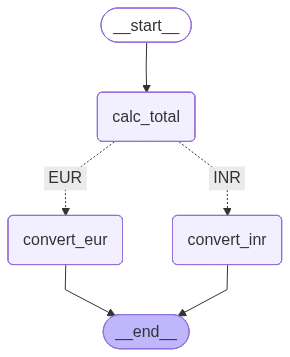

In [13]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
graph.invoke({'amount_usd':1000,'target_currency':'INR'})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'total': 91800.0,
 'target_currency': 'INR'}

In [15]:
graph.invoke({'amount_usd':1000,'target_currency':'EUR'})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'total': 972.0,
 'target_currency': 'EUR'}